In [ ]:
from dmipy.core.modeling_framework import MultiCompartmentModel
from dmipy.signal_models import cylinder_models, sphere_models, gaussian_models
from dmipy.distributions.distribute_models import SD1WatsonDistributed
from dmipy.core.acquisition_scheme import acquisition_scheme_from_bvalues
import numpy as np

c:\Users\wesveng\Documents\PhD\Projects\2026-007_microglia_ECS\analysis\diffusion\mcm\dmipy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\wesveng\Documents\PhD\Projects\2026-007_microglia_ECS\analysis\diffusion\mcm\dmipy\Lib\site-packages\dmipy\utils\utils.py:6: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  SPHERE = get_sphere('symmetric362')
c:\Users\wesveng\Documents\PhD\Projects\2026-007_microglia_ECS\analysis\diffusion\mcm\dmipy\Lib\site-packages\dmipy\optimizers_fod\csd_cvxpy.py:7: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere = get_sphere('symmetric724')
c:\Users\wesveng\Documents\PhD\Projects\2026-007_microglia_ECS\analysis\di

In [ ]:
from dmipy.core import modeling_framework
from dmipy.core.acquisition_scheme import acquisition_scheme_from_bvalues
from os.path import join
import numpy as np

bvalues = np.loadtxt('bvals_merged_new')  # given in s/mm^2
bvalues_SI = bvalues * 1e6  # now given in SI units as s/m^2

gradient_directions = np.loadtxt('bvecs_new')  # on the unit sphere
gradient_directions = np.transpose(gradient_directions)

delta = np.loadtxt('small_delta_new')
delta = delta / 1000
Delta = np.loadtxt('big_delta_new.txt')
Delta = Delta / 1000

acq_scheme = acquisition_scheme_from_bvalues(bvalues_SI, gradient_directions, delta, Delta)

acq_scheme.print_acquisition_info


ValueError: operands could not be broadcast together with shapes (252,2) (0,) 

In [47]:
import dipy
acquisition_splitted = "/Users/frank/Downloads/CUS_mice/NiftiCUS10/gibbs_all"
mask_splitted = "/Users/frank/Downloads/CUS_mice/NiftiCUS10/gibbs_splitted_mask"
data = dipy.data.fetcher.load_nifti_data(join(acquisition_splitted,"gibbs_all__0011.nii.gz"))
mask_file = dipy.data.fetcher.load_nifti_data(join(mask_splitted,"gibbs_mask_0011.nii.gz"))

In [55]:
# C1Stick
# lambda_par = isotropic diffusivity in m^2/s
#astrosticks = cylinder_models.C1Stick(mu=None,lambda_par=None)
astrosticks = cylinder_models.C1Stick()

# Spheres
#diameter=None, diffusion_constant=1.7e-09
sphere_small = sphere_models.S4SphereGaussianPhaseApproximation(diffusion_constant=1.0e-09)
#sphere_small = sphere_models.S2SphereStejskalTannerApproximation()
sphere_large = sphere_models.S4SphereGaussianPhaseApproximation(diffusion_constant=1.0e-09)
#sphere_large = sphere_models.S2SphereStejskalTannerApproximation()


# Hindered
#hindered = gaussian_models.G2Zeppelin(mu=None, lambda_par=None, lambda_perp=None)
hindered = gaussian_models.G2Zeppelin()

# Free
# lambda_iso = isotropic diffusivity in m^2/s -> FW 3 x10-3 mm2/s
free_water_ball = gaussian_models.G1Ball(lambda_iso= 3.0e-09)

# Configure the model with a Watson distribution for fiber orientation dispersion
watson_distribution = SD1WatsonDistributed(models=[astrosticks, hindered])
watson_distribution.set_fixed_parameter('C1Stick_1_lambda_par', 1.0e-9)

# `mu` represents the main orientation in spherical coordinates (theta, phi)
# `kappa` is the concentration parameter of the Watson distribution, related to dispersion

In [56]:
# Set up compartments incl. dispersed bundle
model = MultiCompartmentModel(models=[sphere_small, sphere_large, watson_distribution, free_water_ball])
model.set_fixed_parameter('G1Ball_1_lambda_iso', 3.0e-09)
#model.set_parameter_optimization_bounds('G2Zeppelin_1_lambda_par', [0.1e-09, 2.9e-09])
#model.set_parameter_optimization_bounds('G2Zeppelin_1_lambda_perp', [0.1e-09, 2.9e-09])
model.set_parameter_optimization_bounds('S4SphereGaussianPhaseApproximation_1_diameter', [0.1e-06, 12.0e-06])
model.set_parameter_optimization_bounds('S4SphereGaussianPhaseApproximation_2_diameter', [12.1e-06, 24.0e-06])
#model.set_parameter_optimization_bounds('S2SphereStejskalTannerApproximation_1_diameter', [0.1e-06, 12.0e-06])
#model.set_parameter_optimization_bounds('S2SphereStejskalTannerApproximation_2_diameter', [12.1e-06, 24.0e-06])
#Can also restrict fractions:
#model.set_parameter_optimization_bounds('partial_volume_2', [0.1, 1])
#model.set_parameter_optimization_bounds('partial_volume_3', [0.1, 1])
#model.set_parameter_optimization_bounds('partial_volume_0', [0.01, 0.50])  
#model.set_parameter_optimization_bounds('SD1WatsonDistributed_1_SD1Watson_1_odi', [0.01, 0.8])  

We highly recommend installing pathos to take advantage of multicore processing.


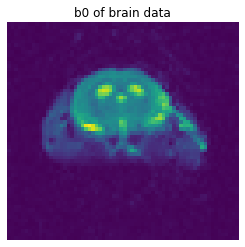

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(data[:,:,0,0])
plt.title('b0 of brain data')
plt.axis('off');

In [23]:
data.shape

(62, 66, 1, 252)

In [24]:
mask_file.shape

(62, 66)

In [57]:
model.parameter_cardinality

OrderedDict([('S4SphereGaussianPhaseApproximation_1_diameter', 1),
             ('S4SphereGaussianPhaseApproximation_2_diameter', 1),
             ('SD1WatsonDistributed_1_SD1Watson_1_mu', 2),
             ('SD1WatsonDistributed_1_SD1Watson_1_odi', 1),
             ('G2Zeppelin_1_lambda_par', 1),
             ('G2Zeppelin_1_lambda_perp', 1),
             ('partial_volume_0', 1),
             ('partial_volume_1', 1),
             ('partial_volume_2', 1),
             ('partial_volume_3', 1),
             ('partial_volume_4', 1)])

In [52]:
data=np.squeeze(data)
mask_file=np.squeeze(mask_file)

In [58]:
microg_fit = model.fit(
    acq_scheme, data, mask=mask_file,
    solver='mix', maxiter=100)
fitted_parameters = microg_fit.fitted_parameters

Setup MIX optimizer in 2.9087066650390625e-05 seconds
Fitting of 677 voxels complete in 7664.948461055756 seconds.
Average of 11.321932734203479 seconds per voxel.


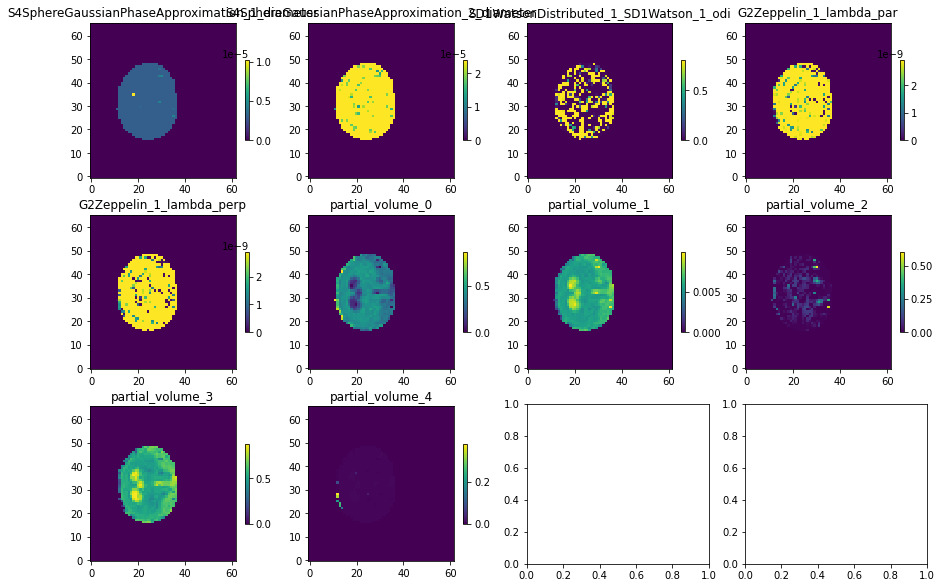

In [59]:
microg_fit.fitted_parameters

fitted_parameters = microg_fit.fitted_parameters

fig, axs = plt.subplots(3, 4, figsize=[15, 10])
axs = axs.ravel()

counter = 0
for name, values in fitted_parameters.items():
    if values.squeeze().ndim != 2:
        continue
    #cf = axs[counter].imshow(values.squeeze().T, origin=True, interpolation='nearest')#
    cf = axs[counter].imshow(values.squeeze().T, origin='lower',interpolation='nearest')
    axs[counter].set_title(name)
    fig.colorbar(cf, ax=axs[counter], shrink=0.5)
    counter += 1

In [39]:
fitted_parameters
import scipy
from scipy.io import savemat
scipy.io.savemat('test.mat', fitted_parameters)